### 구글 드라이브 마운트

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 라이브러리 import

In [17]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader, random_split
from tqdm.notebook import tqdm
import copy
import random

### 데이터셋 로드

In [18]:
pgv_path = '/content/drive/MyDrive/TriAI/그로쓰/Data/processed/pgv/tohoku/processed_pgv_data2.csv'
seismic_path = '/content/drive/MyDrive/TriAI/그로쓰/Data/processed/seismic/tohoku/tohoku_dataset_NEW2.npz'


BATCH_SIZE = 8
NUM_EPOCHS = 20
LEARNING_RATE = 0.001

In [19]:
class Dataset(Dataset):
    def __init__(self, pgv_path, seismic_path, is_train=True):
        seismic_data = np.load(seismic_path, allow_pickle=True)
        self.seismic = seismic_data['data']
        self.station_names = seismic_data['station_names']

        pgv_data = pd.read_csv(pgv_path)

        self.pgv_dict = dict(zip(
            pgv_data['station'].astype(str).str.strip(),
            pgv_data['pgv']
        ))

    def __len__(self):
        return len(self.seismic)

    def __getitem__(self, idx):
        seismic = np.copy(self.seismic[idx])
        station_name = str(self.station_names[idx]).strip()

        # 로그 스케일링
        raw_pgv = self.pgv_dict.get(station_name, 0.0)
        pgv_label = np.log1p(raw_pgv)

        # Data Augmentation
        if self.is_train:
            # Scale Amplitude
            if random.random() < 0.3:
                scale_factor = random.uniform(0.5, 2.0)
                seismic *= scale_factor

            # Drop Channel
            if random.random() < 0.2:
                c1, c2, c3 = random.choice([0, 1]), random.choice([0, 1]), random.choice([0, 1])
                if c1 + c2 + c3 > 0:
                    if c1 == 0: seismic[:, 0] = 0
                    if c2 == 0: seismic[:, 1] = 0
                    if c3 == 0: seismic[:, 2] = 0

            # Add Gaussian Noise
            if random.random() < 0.3:
                for ch in range(3):
                    noise_amp = random.uniform(0.01, 0.15) * np.max(np.abs(seismic[:, ch]) + 1e-8)
                    seismic[:, ch] += np.random.normal(0, noise_amp, seismic.shape[0])

        seismic = seismic.transpose(1, 0)

        # 정규화
        seismic = seismic.astype(np.float32)
        mean = np.mean(seismic, axis=-1, keepdims=True)
        std = np.std(seismic, axis=-1, keepdims=True)
        seismic = (seismic - mean) / (std + 1e-8)

        x_tensor = torch.tensor(seismic, dtype=torch.float32)
        y_tensor = torch.tensor([pgv_label], dtype=torch.float32)

        return x_tensor, y_tensor

### Seismic model

In [20]:
class ResNetBlock(nn.Module):
    def __init__(self, filters, kernel_size, drop_rate):
        super(ResNetBlock, self).__init__()
        padding = kernel_size // 2

        self.bn1 = nn.BatchNorm1d(filters)
        self.drop1 = nn.Dropout1d(drop_rate)
        self.conv1 = nn.Conv1d(filters, filters, kernel_size, padding=padding)

        self.bn2 = nn.BatchNorm1d(filters)
        self.drop2 = nn.Dropout1d(drop_rate)
        self.conv2 = nn.Conv1d(filters, filters, kernel_size, padding=padding)

    def forward(self, x):
        res = x
        # 첫 번째 레이어
        out = self.bn1(x)
        out = F.relu(out)
        out = self.drop1(out)
        out = self.conv1(out)
        # 두 번째 레이어
        out = self.bn2(out)
        out = F.relu(out)
        out = self.drop2(out)
        out = self.conv2(out)
        # 잔차 연결 (Add)
        return out + res


class BiLSTMBlock(nn.Module):
    def __init__(self, in_channels, filters, drop_rate):
        super(BiLSTMBlock, self).__init__()
        self.drop_rate = drop_rate
        self.bilstm = nn.LSTM(input_size=in_channels, hidden_size=filters,
                              num_layers=1, batch_first=True, bidirectional=True)
        self.nin = nn.Conv1d(filters * 2, filters, kernel_size=1)
        self.bn = nn.BatchNorm1d(filters)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = F.dropout(x, p=self.drop_rate, training=self.training)

        out, _ = self.bilstm(x)

        out = out.permute(0, 2, 1)
        out = self.nin(out)
        out = self.bn(out)
        return out


class EQTEncoder(nn.Module):
    def __init__(self, drop_rate=0.1, output_dim=128):
        super(EQTEncoder, self).__init__()

        filters = [8, 16, 16, 32, 32, 96, 96]
        kernels = [11, 9, 7, 7, 5, 5, 3]

        # Conv
        self.encoder_convs = nn.ModuleList()
        in_c = 3
        for out_c, k in zip(filters, kernels):
            self.encoder_convs.append(nn.Sequential(
                nn.Conv1d(in_c, out_c, kernel_size=k, padding=k//2),
                nn.ReLU(),
                nn.MaxPool1d(2)
            ))
            in_c = out_c

        # ResCNN
        self.resnet_blocks = nn.ModuleList()
        for cb in range(5):
            self.resnet_blocks.append(ResNetBlock(96, kernel_size=3, drop_rate=drop_rate))
            if cb > 2:
                self.resnet_blocks.append(ResNetBlock(96, kernel_size=3, drop_rate=drop_rate))

        # Bi-LSTM / NiN
        self.bilstm_blocks = nn.ModuleList()
        lstm_in_c = 96
        for _ in range(3):
            self.bilstm_blocks.append(BiLSTMBlock(in_channels=lstm_in_c, filters=16, drop_rate=drop_rate))
            lstm_in_c = 16

        # Transformer
        encoder_layer = nn.TransformerEncoderLayer(d_model=16, nhead=2, dim_feedforward=128,
                                                   dropout=drop_rate, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)

        # 특징맵 차원 조정
        self.final_projection = nn.Linear(16, output_dim)

    def forward(self, x):
        for conv in self.encoder_convs:
            x = conv(x)
        for resnet in self.resnet_blocks:
            x = resnet(x)
        for bilstm in self.bilstm_blocks:
            x = bilstm(x)
        x = x.permute(0, 2, 1)
        x = self.transformer(x)

        feature_map = self.final_projection(x)

        return feature_map


class Decoder(nn.Module):
	def __init__(self, input_dim=128, hidden_dim=64, output_dim=1):
		super(Decoder, self).__init__()

		# 1. Attention Pooling
		self.attention = nn.Linear(input_dim, 1)

		# 2. MLP
		self.mlp = nn.Sequential(
			nn.Linear(input_dim, hidden_dim),
			nn.BatchNorm1d(hidden_dim),
			nn.ReLU(),
			nn.Dropout(0.3)
		)

		# 3. Regression
		self.regression = nn.Linear(hidden_dim, output_dim)

	def forward(self, x):

		# 1. Attention Pooling
		scores = self.attention(x).squeeze(-1)
		weights = F.softmax(scores, dim=1).unsqueeze(-1)

		context = torch.sum(x * weights, dim=1)

		# 2. MLP
		features = self.mlp(context)

		# 3. Regression
		output = self.regression(features)

		return output

In [21]:
class FullEQTModel(nn.Module):
    def __init__(self):
        super(FullEQTModel, self).__init__()
        self.encoder = EQTEncoder(output_dim=128)
        self.decoder = Decoder(input_dim=128)

    def forward(self, x):
        features = self.encoder(x)
        output = self.decoder(features)
        return output

### Training

In [22]:
def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    full_dataset = Dataset(pgv_path, seismic_path, is_train=False)

    total_size = len(full_dataset)
    train_size = int(total_size * 0.8)
    val_size = total_size - train_size
    train_subset, val_subset = random_split(full_dataset, [train_size, val_size])

    # Train dataset에만 is_train=True를 강제 적용
    train_subset.dataset.is_train = True
    val_subset.dataset.is_train = False

    train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)

    model = FullEQTModel().to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # 지정된 에폭(20, 40, 60, 90)을 통과할 때마다 학습률에 gamma(0.1)를 곱해 감소
    scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[20, 40, 60, 90], gamma=0.1)

    best_val_loss = float('inf')
    best_model_weights = None

    NUM_EPOCHS = 100
    print("=========================== Train ===========================")

    for epoch in range(NUM_EPOCHS):
        # Train
        model.train()
        train_loss = 0.0

        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)

        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)

        # 1에폭이 끝날 때마다 스케줄러 업데이트
        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']

        # 로그 스케일링된 MSE에서 원래 PGV 스케일의 RMSE로 복원하여 출력
        val_rmse_original_scale = np.expm1(avg_val_loss ** 0.5)

        # 최고 성능 갱신 시 모델 자동 저장
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_weights = copy.deepcopy(model.state_dict())

        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] LR: {current_lr:.8f} | "
              f"Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {avg_val_loss:.4f} (Original PGV RMSE: {val_rmse_original_scale:.2f})")

    # 최고 성능 모델 파일로 추출
    torch.save(best_model_weights, 'best_seismic_model.pth')

    # 메모리 상의 모델도 최고 성능 모델로 저장
    model.load_state_dict(best_model_weights)
    return model

if __name__ == '__main__':
    best_model = main()

=========================== Train ===========================
Epoch [1/100] LR: 0.00100000 | Train Loss: 4.9523 | Val Loss: 0.6602 (Original PGV RMSE: 1.25)
Epoch [2/100] LR: 0.00100000 | Train Loss: 0.8929 | Val Loss: 0.5473 (Original PGV RMSE: 1.10)
Epoch [3/100] LR: 0.00100000 | Train Loss: 0.7001 | Val Loss: 0.4535 (Original PGV RMSE: 0.96)
Epoch [4/100] LR: 0.00100000 | Train Loss: 0.7195 | Val Loss: 0.3839 (Original PGV RMSE: 0.86)
Epoch [5/100] LR: 0.00100000 | Train Loss: 0.6493 | Val Loss: 0.4277 (Original PGV RMSE: 0.92)
Epoch [6/100] LR: 0.00100000 | Train Loss: 0.6922 | Val Loss: 0.4681 (Original PGV RMSE: 0.98)
Epoch [7/100] LR: 0.00100000 | Train Loss: 0.6834 | Val Loss: 0.3989 (Original PGV RMSE: 0.88)
Epoch [8/100] LR: 0.00100000 | Train Loss: 0.6779 | Val Loss: 0.4391 (Original PGV RMSE: 0.94)
Epoch [9/100] LR: 0.00100000 | Train Loss: 0.6063 | Val Loss: 0.4160 (Original PGV RMSE: 0.91)
Epoch [10/100] LR: 0.00100000 | Train Loss: 0.5657 | Val Loss: 0.3957 (Original PGV

### Best model 결과 시각화

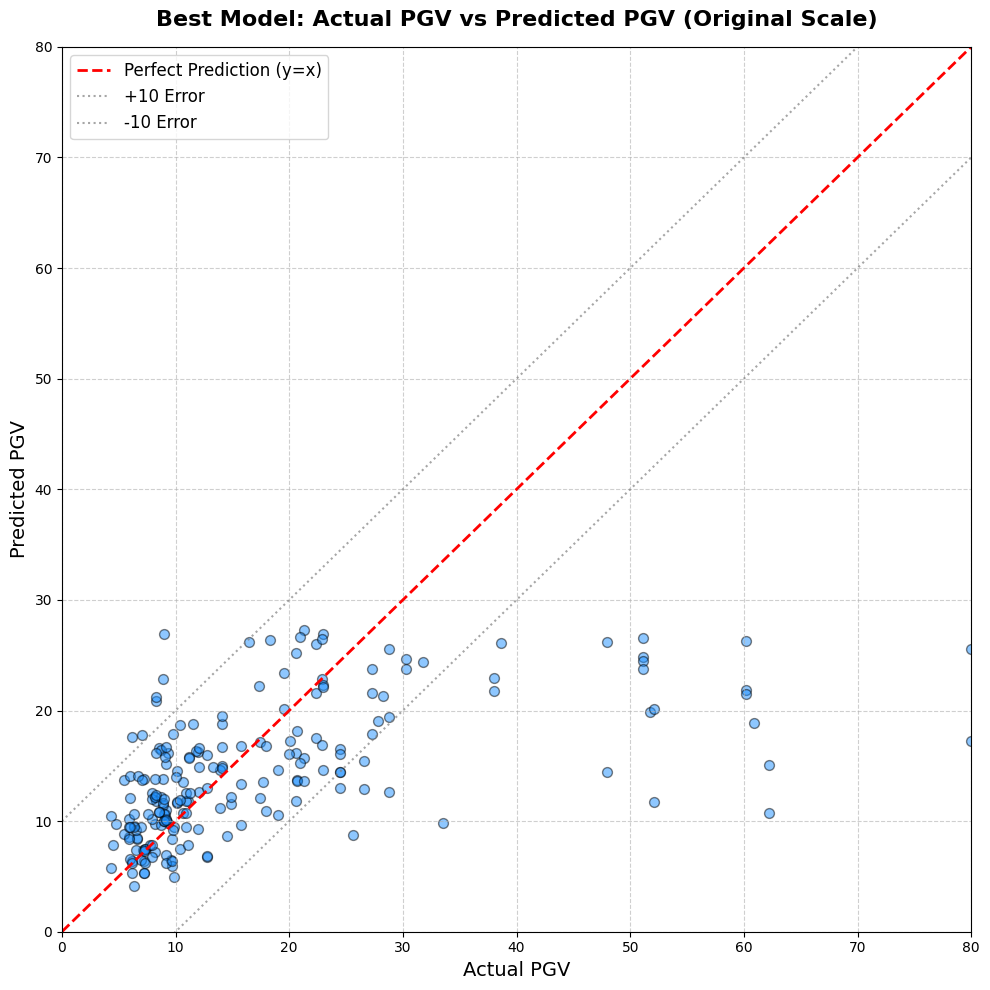

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader, random_split

full_dataset = Dataset(pgv_path, seismic_path, is_train=False)

total_size = len(full_dataset)
train_size = int(total_size * 0.8)
val_size = total_size - train_size

# 데이터 분할 (동일한 검증셋을 얻기 위해 시드 고정)
torch.manual_seed(42)
_, val_subset = random_split(full_dataset, [train_size, val_size])

# 검증용이므로 데이터 증강(Augmentation) 확실히 끄기
val_subset.dataset.is_train = False
val_loader = DataLoader(val_subset, batch_size=8, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
best_model = FullEQTModel().to(device)
best_model.load_state_dict(torch.load('best_seismic_model.pth'))

def plot_best_model_predictions(model, val_loader, device):
    model.eval()

    actuals = []
    predictions = []

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)

            actuals.extend(targets.cpu().numpy().flatten())
            predictions.extend(outputs.cpu().numpy().flatten())

    # 로그 스케일 역변환 (Log -> Original Scale)
    actuals_original = np.expm1(np.array(actuals))
    predictions_original = np.expm1(np.array(predictions))

    # 산점도(Scatter Plot) 그리기
    plt.figure(figsize=(10, 10))
    plt.scatter(actuals_original, predictions_original, alpha=0.5, color='dodgerblue', edgecolor='k', s=50)

    max_val = 80
    plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction (y=x)')
    plt.plot([0, max_val], [10, max_val + 10], color='gray', linestyle=':', alpha=0.7, label='+10 Error')
    plt.plot([0, max_val], [-10, max_val - 10], color='gray', linestyle=':', alpha=0.7, label='-10 Error')

    plt.title('Best Model: Actual PGV vs Predicted PGV (Original Scale)', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Actual PGV', fontsize=14)
    plt.ylabel('Predicted PGV', fontsize=14)

    plt.xlim(0, max_val)
    plt.ylim(0, max_val)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()

plot_best_model_predictions(best_model, val_loader, device)